# Задание 1
Что нужно сделать
* Первое задание — проанализировать датасет. В коде ниже уже написана загрузка датасета и чистка текстов в нём — приведение к нижнему регистру и удаление лишних символов.
Вам нужно:
Посчитать распределение классов в датасете.
Это поможет нам выбрать метрику, которая либо будет учитывать дисбаланс классов, либо нет. Также модели могут переобучиться под один класс, если их слишком много. Анализ соотношения классов поможет спланировать дальнейшие шаги.
* Посчитать статистики по количеству слов в текстах датасета. Для подсчёта статистик лучше использовать сторонние библиотеки. NumPy — одна из них.
Подсчёт статистики важен для нас, ведь чем длиннее тексты, тем больше вычислительных ресурсов нам понадобится. Этот фактор тоже хочется учесть заранее.
* Для подсчёта количества классов передайте список df['label'] в конструктор Counter.
* Среднее, медиану и перцентили можно посчитать функциями np.mean, np.median и np.percentile.

README.md: 0.00B [00:00, ?B/s]

c:\Users\aseva\Desktop\MyEDU\YaDLE\YaDLE_project_vscode_stream_2\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aseva\.cache\huggingface\hub\datasets--amazon_polarity. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. 

train-00000-of-00004.parquet:   0%|          | 0.00/260M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


train-00001-of-00004.parquet:   0%|          | 0.00/258M [00:00<?, ?B/s]

...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


test-00000-of-00001.parquet:   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Распределение классов:
Класс 1: 101166 примеров
Класс 0: 98834 примеров

Статистика по количеству слов в тексте:
Среднее: 78.19
Медиана: 70.00
5-й перцентиль: 22.00
95-й перцентиль: 163.00


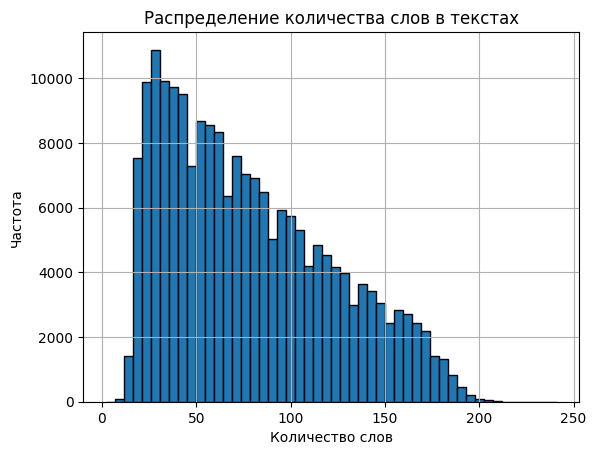

In [ ]:
import re
import numpy as np
import pandas as pd
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt


In [ ]:

# 1. Загрузка датасета
now_load_and_save_downloaded_dataset = False

if now_load_and_save_downloaded_dataset:
    dataset = load_dataset("amazon_polarity", split="train[:200000]") 
    texts, labels = dataset['content'], list(dataset['label'])

In [ ]:

# 1.bis Сохранение датасета локально в pandas-формате
if now_load_and_save_downloaded_dataset:
    pd.DataFrame(
        index=['title','label','content'],
        data=[
            dataset['title'],
            dataset['label'],
            dataset['content']
        ]
    ).T.to_csv('../data/amazon_dataset.csv', sep=';', index=False)


Распределение классов:
Класс 1: 101166 примеров
Класс 0: 98834 примеров

Статистика по количеству слов в тексте:
Среднее: 78.19
Медиана: 70.00
5-й перцентиль: 22.00
95-й перцентиль: 163.00


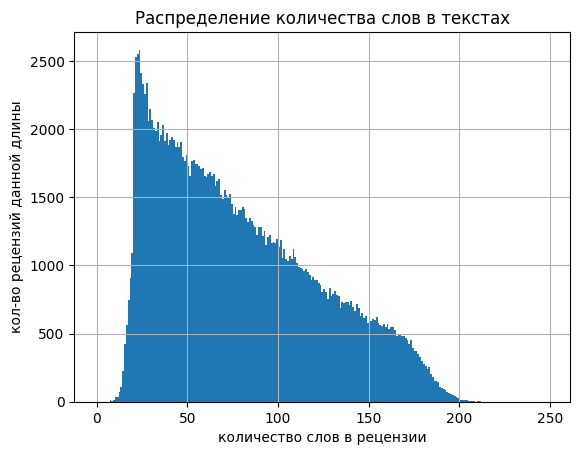

In [24]:

# 2. Очистка текстов
def clean_text(text):
    text = text.lower()  # к нижнему регистру
    text = re.sub(r"[^a-z0-9 ]+", " ", text)  # оставить только буквы и цифры
    text = re.sub(r"\s+", " ", text).strip()  # убрать дублирующиеся пробелы
    return text

if not now_load_and_save_downloaded_dataset:
    ddf = pd.read_csv('../data/amazon_dataset.csv', sep=';')
    texts, labels = list(ddf['content']), list(ddf['label'])

texts = [clean_text(text) for text in texts]


# 3. Распределение классов
label_counts = Counter(dataset["label"])
print("Распределение классов:")
for label, count in label_counts.items():
    print(f"Класс {label}: {count} примеров")


# 4. Статистика по количеству слов
word_counts = [len(text.split()) for text in texts]


print("\nСтатистика по количеству слов в тексте:")
print(f"Среднее: {np.mean(word_counts):.2f}")
print(f"Медиана: {np.median(word_counts):.2f}")
print(f"5-й перцентиль: {np.percentile(word_counts, 5):.2f}")
print(f"95-й перцентиль: {np.percentile(word_counts, 95):.2f}")


# 5. Гистограмма распределения длины
plt.hist(word_counts, bins=range(250))
plt.title("Распределение количества слов в текстах")
plt.xlabel("количество слов в рецензии")
plt.ylabel("кол-во рецензий данной длины")
plt.grid(True)
plt.show()